<a href="https://colab.research.google.com/github/udaycharanrada/Weather-Recognition/blob/main/Weather_ImageRecognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install --upgrade kaggle

In [ ]:
from google.colab import files
files.upload()

Saving pic.jpg to pic.jpg


{'pic.jpg': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xfe\x00<CREATOR: gd-jpeg v1.0 (using IJG JPEG v62), quality = 100\n\xff\xdb\x00C\x00\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\xff\xdb\x00C\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\x01\xff\xc0\x00\x11\x08\x04\xb0\x04\xb0\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1f\x00\x00\x01\x05\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b\xff\xc4\x00\xb5\x10\x00\x02\x01\x03\x03\x02\x04\x03\x05\x05\x04\x04\x00\x00\x01}\x01\x02\x03\x00\x

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
!kaggle datasets download -d jehanbhathena/weather-dataset
!unzip weather-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: dataset/frost/3913.jpg  
  inflating: dataset/frost/3914.jpg  
  inflating: dataset/frost/3915.jpg  
  inflating: dataset/frost/3916.jpg  
  inflating: dataset/frost/3917.jpg  
  inflating: dataset/frost/3918.jpg  
  inflating: dataset/frost/3919.jpg  
  inflating: dataset/frost/3920.jpg  
  inflating: dataset/frost/3921.jpg  
  inflating: dataset/frost/3922.jpg  
  inflating: dataset/frost/3923.jpg  
  inflating: dataset/frost/3924.jpg  
  inflating: dataset/frost/3925.jpg  
  inflating: dataset/frost/3926.jpg  
  inflating: dataset/frost/3927.jpg  
  inflating: dataset/frost/3928.jpg  
  inflating: dataset/frost/3929.jpg  
  inflating: dataset/frost/3930.jpg  
  inflating: dataset/frost/3931.jpg  
  inflating: dataset/frost/3932.jpg  
  inflating: dataset/frost/3933.jpg  
  inflating: dataset/frost/3934.jpg  
  inflating: dataset/frost/3935.jpg  
  inflating: dataset/frost/3936.jpg  
  inflating: dataset/frost/3937.jpg  

In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Define paths
original_dataset_path = "/content/dataset"  # Ensure this path is correct
output_path = "/content/weather_data_split"

# Create train and validation directories
train_dir = os.path.join(output_path, "train")
val_dir = os.path.join(output_path, "val")
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

# Get all class names (subfolders)
classes = os.listdir(original_dataset_path)

for cls in classes:
    cls_path = os.path.join(original_dataset_path, cls)

    # Ensure it's a directory
    if not os.path.isdir(cls_path):
        continue

    # Filter only valid images
    images = [img for img in os.listdir(cls_path) if img.endswith(('.jpg', '.png', '.jpeg'))]

    if len(images) == 0:
        print(f"⚠️ Skipping empty class folder: {cls}")
        continue

    # Split into 80% train and 20% validation
    train_images, val_images = train_test_split(images, test_size=0.2, random_state=42)

    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(val_dir, cls), exist_ok=True)

    # Move images to the train folder
    for img in train_images:
        src = os.path.join(cls_path, img)
        dst = os.path.join(train_dir, cls, img)
        shutil.move(src, dst)

    # Move images to the validation folder
    for img in val_images:
        src = os.path.join(cls_path, img)
        dst = os.path.join(val_dir, cls, img)
        shutil.move(src, dst)

print("✅ Dataset successfully split into Train and Validation sets!")

✅ Dataset successfully split into Train and Validation sets!


In [ ]:
import torch
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define Transformations (Preprocessing)
transform = transforms.Compose([
    transforms.Resize((128, 128)),   # Resize images
    transforms.RandomHorizontalFlip(),  # Data Augmentation
    transforms.RandomRotation(20),      # Data Augmentation
    transforms.ToTensor(),   # Convert images to PyTorch tensors
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalize
])

# Define dataset path
dataset_path = "/content/weather_data_split"  # Path of the split dataset

# Load train and validation data
train_data = datasets.ImageFolder(root=dataset_path + "/train", transform=transform)
val_data = datasets.ImageFolder(root=dataset_path + "/val", transform=transform)

# Create DataLoaders
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)

# Check data loaded successfully
print(f"Classes: {train_data.classes}")
print(f"Total Train Images: {len(train_data)}")
print(f"Total Validation Images: {len(val_data)}")

Classes: ['dew', 'fogsmog', 'frost', 'glaze', 'hail', 'lightning', 'rain', 'rainbow', 'rime', 'sandstorm', 'snow']
Total Train Images: 5484
Total Validation Images: 1378


In [ ]:
import torch
import torchvision.models as models

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")  # Output: cuda (if GPU is available)

# Load VGG19 model
model = models.vgg19(pretrained=True)
model.to(device)  # Move model to GPU

# Example: Moving data to GPU
images = torch.randn(32, 3, 224, 224)  # Fake batch of 32 images
images = images.to(device)  # Move images to GPU

# Forward pass
outputs = model(images)

Using device: cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:03<00:00, 191MB/s]


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

# Define Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# Load Pretrained VGG19 Model
vgg19 = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)

# Modify Classifier for Custom Dataset
num_classes = len(train_data.classes)  # Get the number of classes in the dataset

# Replace the last layer in the classifier
vgg19.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)  # Output layer with 'num_classes' neurons
)

# Move model to GPU (if available)
vgg19 = vgg19.to(device)

# Print Model Summary
print(vgg19)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [ ]:
import torch.optim as optim

# Define Loss Function (Cross Entropy for Classification)
criterion = nn.CrossEntropyLoss()

# Define Optimizer (Adam)
optimizer = optim.Adam(vgg19.parameters(), lr=0.0001)

In [ ]:
from tqdm import tqdm  # For showing progress bar

# Training Parameters
num_epochs = 10  # You can increase it
train_loss = []
val_loss = []

for epoch in range(num_epochs):
    vgg19.train()  # Set to training mode
    running_loss = 0.0

    # Training loop
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images, labels = images.to(device), labels.to(device)

        # Forward Pass
        optimizer.zero_grad()
        outputs = vgg19(images)
        loss = criterion(outputs, labels)

        # Backward Pass
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_loss.append(avg_train_loss)

    # Validation Phase
    vgg19.eval()
    val_running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = vgg19(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()

            # Accuracy Calculation
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_val_loss = val_running_loss / len(val_loader)
    val_loss.append(avg_val_loss)
    accuracy = correct / total * 100

    # Print Epoch Results
    print(f"Epoch [{epoch+1}/{num_epochs}] -> Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Accuracy: {accuracy:.2f}%")

print("Training Complete! 🚀")

Epoch 1/10: 100%|██████████| 172/172 [01:02<00:00,  2.76it/s]


Epoch [1/10] -> Train Loss: 0.9390, Val Loss: 0.6124, Accuracy: 82.58%


Epoch 2/10: 100%|██████████| 172/172 [01:02<00:00,  2.74it/s]


Epoch [2/10] -> Train Loss: 0.5185, Val Loss: 0.5361, Accuracy: 82.80%


Epoch 3/10: 100%|██████████| 172/172 [01:03<00:00,  2.71it/s]


...

Epoch [8/10] -> Train Loss: 0.2448, Val Loss: 0.4417, Accuracy: 85.99%


Epoch 9/10: 100%|██████████| 172/172 [01:04<00:00,  2.68it/s]


Epoch [9/10] -> Train Loss: 0.2442, Val Loss: 0.6104, Accuracy: 88.03%


Epoch 10/10: 100%|██████████| 172/172 [01:04<00:00,  2.68it/s]


Epoch [10/10] -> Train Loss: 0.2845, Val Loss: 0.4208, Accuracy: 88.17%
Training Complete! 🚀


In [ ]:
torch.save(vgg19.state_dict(), "vgg19_weather_classification.pth")
print("Model Saved Successfully! 🎉")

Model Saved Successfully! 🎉


In [ ]:
model = vgg19  # Reuse the trained model
model.load_state_dict(torch.load("vgg19_weather_classification.pth"))
model.to(device)
model.eval()

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

✅ Validation Accuracy: 0.8846

🔹 Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.96      0.97       140
           1       0.89      0.98      0.93       171
           2       0.92      0.72      0.80        95
           3       0.70      0.90      0.78       128
           4       0.94      0.94      0.94       119
           5       0.99      0.99      0.99        76
           6       0.88      0.91      0.89       106
           7       1.00      0.94      0.97        47
           8       0.93      0.78      0.85       232
           9       0.95      0.88      0.92       139
          10       0.72      0.82      0.77       125

    accuracy                           0.88      1378
   macro avg       0.90      0.89      0.89      1378
weighted avg       0.89      0.88      0.89      1378



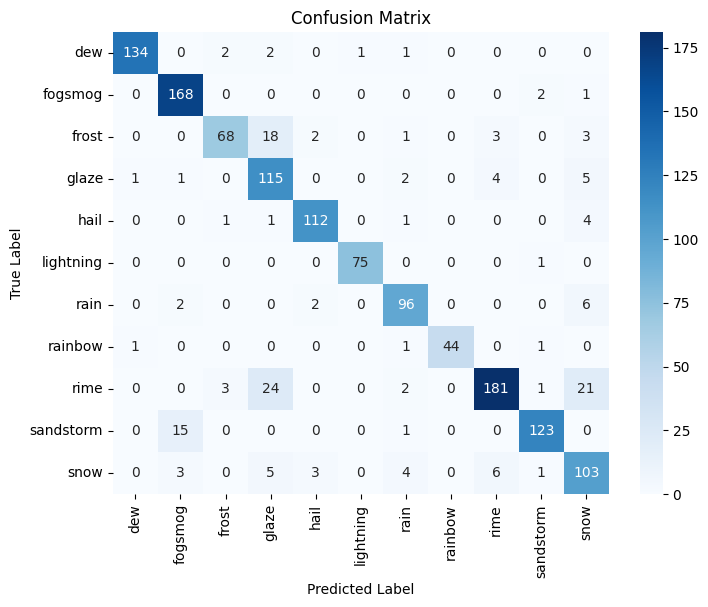

In [ ]:
import torch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Store predictions and labels
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# Accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f"✅ Validation Accuracy: {accuracy:.4f}")

# Classification Report
print("\n🔹 Classification Report:\n", classification_report(y_true, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=train_data.classes, yticklabels=train_data.classes)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

Saving pic.jpg to pic (1).jpg
Uploaded Image: pic (1).jpg


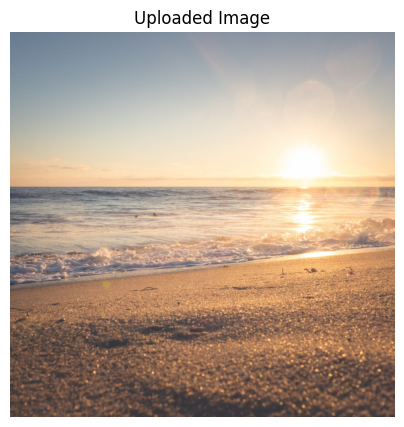

Predicted Weather Condition: sandstorm


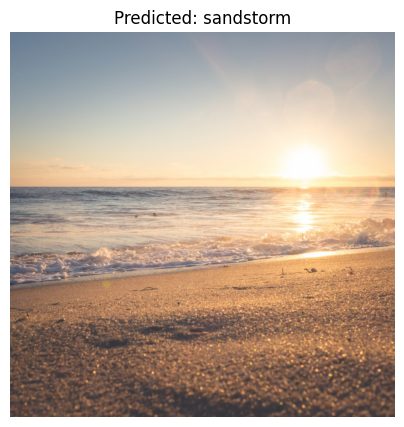

In [ ]:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import torch


uploaded = files.upload()  # Uploads an image file
image_path = list(uploaded.keys())[0]  # Get uploaded filename
print(f"Uploaded Image: {image_path}")

# Load Image
image = Image.open(image_path)

# Display the Input Image
plt.figure(figsize=(5,5))
plt.imshow(image)
plt.axis("off")
plt.title("Uploaded Image")
plt.show()

# Preprocess Image
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])
image_tensor = transform(image).unsqueeze(0).to(device)


vgg19.eval()
with torch.no_grad():
    output = vgg19(image_tensor)
    _, predicted = torch.max(output, 1)


class_names = train_data.classes
predicted_label = class_names[predicted.item()]

print(f"Predicted Weather Condition: {predicted_label}")

plt.figure(figsize=(5,5))
plt.imshow(Image.open(image_path))
plt.axis("off")
plt.title(f"Predicted: {predicted_label}")
plt.show()